# Supervised Contrastive Learning for TE Clustering (V5, split-fix variant)

Forked from `data_analysis/vgp_model_clustering/constrastive_clustering_v5/`.
Only difference: the encoder is initialised from the **Stage-2 v4.3 hybrid checkpoint**
(`hybrid_v4.3_epoch40.pt`, species-disjoint outer split + rotating-CV inner)
instead of the original v4-era Stage-1 encoder. Towers (`cnn_tower`, `gnn_tower`,
`fusion`) load directly via the existing `from_v4_checkpoint` classmethod;
incompatible heads (`class_head`, 23-way `superfamily_head`) are filtered and
re-initialised for the DNA-only contrastive task.

## Approach
1. Load **Stage-2 v4.3** hybrid model (CNN + K-mer GNN with built-in RC-invariance)
2. Filter to DNA-positive sequences with specific superfamily labels
3. Replace multi-class head with contrastive projection head
4. Train with SupCon + Classification + Center loss
5. Evaluate clustering with K-Means and HDBSCAN
6. Visualize embeddings with UMAP

Local-MPS-friendly: BatchNorm only (no GroupNorm), small batch, AdamW LR 1e-4,
no MixUp / label-smoothed CE — see `/memories/repo/mps_pitfalls.md`.


In [1]:
# ============ Imports ============
import gc
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import Counter
from tqdm.auto import tqdm
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans, HDBSCAN

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.0
CUDA available: False
MPS available: True


In [2]:
# ============ Configuration ============
FASTA_PATH = "../../../data/vgp/all_vgp_tes.fa"
LABEL_PATH = "../../../data/vgp/20260120_features_sf"
# Stage-2 v4.3 hybrid encoder (rotating-CV inner; species-disjoint outer)
V4_CHECKPOINT_PATH = "../v4.3/cluster session/hybrid_v4.3_epoch40.pt"
SAVE_DIR = "."  # outputs (checkpoints, embeddings, plots) drop here

# Model hyperparameters (must match v4.3 checkpoint arch dict)
FIXED_LENGTH = 20000
KMER_K = 7
KMER_DIM = 2048
KMER_WINDOW = 512
KMER_STRIDE = 256
GNN_HIDDEN = 128
GNN_LAYERS = 3
CNN_WIDTH = 128
MOTIF_KERNELS = (7, 15, 21)
CONTEXT_DILATIONS = (1, 2, 4, 8)
RC_FUSION_MODE = "late"
FUSION_DIM = 256
NUM_HEADS = 4

# Contrastive learning parameters
PROJ_DIM = 128           # Projection head output dimension
TEMPERATURE = 0.3        # SupCon temperature (raised from 0.1 to boost alignment)
BATCH_SIZE = 32          # Batch size for contrastive learning
EPOCHS = 30              # Reduced from 50 for local MPS run; bump to 50 if budget allows
LR = 1e-4                # Lower LR for fine-tuning
ENCODER_LR_MULT = 0.1    # Encoder LR multiplier

# Multi-task loss weights
CLASSIFY_WEIGHT = 0.5    # Weight for cross-entropy classification loss
CENTER_WEIGHT = 0.01     # Weight for center loss (alignment)
CENTER_LR = 0.5          # Learning rate for center loss centroids

# DNA superfamily filtering
MIN_SAMPLES_PER_SF = 100  # Minimum samples per superfamily to include

def resolve_device(requested=None):
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")
print(f"Encoder source: {V4_CHECKPOINT_PATH}")


Using device: mps
Encoder source: ../v4.3/cluster session/hybrid_v4.3_epoch40.pt


## Data Loading Utilities

In [3]:
# ============ FASTA and Label Loading ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


def load_dna_sequences(fasta_path, label_path, min_samples_per_sf=100):
    """
    Load DNA transposon sequences using ground-truth labels from 20260120_features_sf.
    
    Filters to DNA superfamilies with specific sub-class labels (e.g. DNA/hAT),
    excluding generic 'DNA' label and non-DNA classes.
    
    Args:
        fasta_path: Path to FASTA file
        label_path: Path to label file (header<TAB>superfamily)
        min_samples_per_sf: Minimum samples per superfamily
    
    Returns:
        headers, sequences, superfamilies: matched lists
    """
    # Load labels
    label_dict = {}
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            
            # Keep only specific DNA superfamilies (must have DNA/*)
            if tag.startswith('DNA/'):
                label_dict[header] = tag
    
    print(f"DNA sequences with specific superfamily labels: {len(label_dict)}")
    
    # Count superfamilies and filter rare ones
    sf_counts = Counter(label_dict.values())
    print(f"\nAll DNA superfamilies ({len(sf_counts)}):")
    for sf, count in sorted(sf_counts.items(), key=lambda x: -x[1]):
        marker = "✓" if count >= min_samples_per_sf else "✗"
        print(f"  {marker} {sf}: {count}")
    
    valid_sfs = {sf for sf, count in sf_counts.items() if count >= min_samples_per_sf}
    print(f"\nKeeping {len(valid_sfs)} superfamilies with >= {min_samples_per_sf} samples")
    
    # Load FASTA and match
    all_headers, all_sequences = read_fasta(fasta_path)
    seq_dict = dict(zip(all_headers, all_sequences))
    
    headers, sequences, superfamilies = [], [], []
    for h, tag in tqdm(label_dict.items(), desc="Matching sequences"):
        if tag in valid_sfs and h in seq_dict:
            headers.append(h)
            sequences.append(seq_dict[h])
            superfamilies.append(tag)
    
    print(f"\nMatched {len(headers)} sequences")
    
    sf_counts_final = Counter(superfamilies)
    print(f"Final superfamily distribution ({len(sf_counts_final)} classes):")
    for sf, count in sorted(sf_counts_final.items(), key=lambda x: -x[1]):
        print(f"  {sf}: {count} ({100*count/len(superfamilies):.1f}%)")
    
    return headers, sequences, superfamilies

## K-mer Feature Extraction

In [4]:
# ============ K-mer Feature Extraction ============

# ASCII -> {0,1,2,3,4} for A,C,G,T,other
_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch, val in [("A", 0), ("C", 1), ("G", 2), ("T", 3), ("a", 0), ("c", 1), ("g", 2), ("t", 3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3, 2, 1, 0], dtype=np.uint8)  # A<->T, C<->G


def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code


def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code


def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2


def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)


@dataclass
class KmerWindowFeaturizer:
    """Extract k-mer frequency features from sliding windows."""
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, np.ndarray]:
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii", "ignore"), dtype=np.uint8)]
        L = int(arr.size)
        
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i + k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    """Build edge index for a chain graph (windows connected sequentially)."""
    edges = []
    if n > 1:
        src = np.arange(n - 1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2, 0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s, d], axis=0)
    return torch.from_numpy(ei)

## Sequence Encoding for CNN

In [5]:
# ============ Encoding for CNN ============

# Mapping ACGT to 0-3, N to 4
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# Reverse complement: ACGTN -> TGCAN -> indices [3, 2, 1, 0, 4]
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)


def reverse_complement_sequence(seq: str) -> str:
    """Return the reverse complement of a DNA sequence."""
    comp = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N',
            'a': 't', 't': 'a', 'c': 'g', 'g': 'c', 'n': 'n'}
    return ''.join(comp.get(b, 'N') for b in reversed(seq))

## Model Architecture (CNN + GNN Towers from V4)

In [6]:
# ============ CNN Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)


class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p


def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)


class RCFirstConv1d(nn.Module):
    """RC-invariant first convolution (early fusion)."""
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return y

In [7]:
# ============ CNN Tower ============

class CNNTower(nn.Module):
    """
    CNN tower for sequence motif detection.
    Produces a fixed-size embedding from one-hot encoded DNA sequence.
    """
    def __init__(
        self,
        width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_kernel: int = 9,
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "late"
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.out_dim = width
        
        # Motif detection layers
        if rc_mode == "early":
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k // 2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        # Mix layer
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Context blocks with dilation
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

    @staticmethod
    def rc_transform(x, mask):
        """Apply reverse complement transformation."""
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def encode(self, x, mask):
        """Encode sequence through CNN layers."""
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)  # (B, width)

    def forward(self, x, mask):
        """Forward pass with RC handling. Returns: (B, width) embedding"""
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            return 0.5 * (f + r)
        else:
            return self.encode(x, mask)

In [8]:
# ============ GNN Building Blocks ============

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    """Scatter mean for graph pooling."""
    out = torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt = torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out / cnt


class GraphSAGELayer(nn.Module):
    """GraphSAGE-style message passing layer."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)


class GNNTower(nn.Module):
    """
    GNN tower for k-mer composition analysis.
    Produces a fixed-size embedding from k-mer window features.
    """
    def __init__(
        self,
        in_dim: int,
        hidden: int = 128,
        n_layers: int = 3,
        dropout: float = 0.1
    ):
        super().__init__()
        self.out_dim = hidden
        
        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d = hidden
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Args:
            x: (N, in_dim) node features
            edge_index: (2, E) edges
            batch_vec: (N,) batch assignment
        Returns:
            (B, hidden) graph-level embeddings
        """
        for layer in self.layers:
            x = layer(x, edge_index)
        
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        return scatter_mean(x, batch_vec, dim_size=B)

In [9]:
# ============ Cross-Modal Attention Fusion ============

class CrossModalAttentionFusion(nn.Module):
    """
    Fuses CNN and GNN embeddings using cross-modal attention.
    """
    def __init__(
        self,
        cnn_dim: int = 128,
        gnn_dim: int = 128,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.2
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        
        # Project both embeddings to fusion dimension
        self.cnn_proj = nn.Linear(cnn_dim, fusion_dim)
        self.gnn_proj = nn.Linear(gnn_dim, fusion_dim)
        
        # Layer norm before attention
        self.ln1 = nn.LayerNorm(fusion_dim)
        self.ln2 = nn.LayerNorm(fusion_dim)
        
        # Cross-modal attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Learned gating for adaptive fusion
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=-1)
        )
        
        # Output projection
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, cnn_embed: torch.Tensor, gnn_embed: torch.Tensor):
        """
        Args:
            cnn_embed: (B, cnn_dim) from CNN tower
            gnn_embed: (B, gnn_dim) from GNN tower
        Returns:
            fused: (B, fusion_dim) fused embedding
            gate_weights: (B, 2) for interpretability [cnn_weight, gnn_weight]
        """
        # Project to fusion dimension
        c = self.cnn_proj(cnn_embed)
        g = self.gnn_proj(gnn_embed)
        
        # Layer norm
        c = self.ln1(c)
        g = self.ln2(g)
        
        # Stack as sequence: (B, 2, fusion_dim)
        combined = torch.stack([c, g], dim=1)
        
        # Self-attention across modalities
        attn_out, _ = self.cross_attn(combined, combined, combined)
        
        # Extract attended features
        c_attn = attn_out[:, 0]
        g_attn = attn_out[:, 1]
        
        # Learned gating
        gate_input = torch.cat([c_attn, g_attn], dim=-1)
        gate_weights = self.gate(gate_input)
        
        # Weighted fusion
        fused = gate_weights[:, 0:1] * c_attn + gate_weights[:, 1:2] * g_attn
        
        # Output projection
        fused = self.out_proj(fused)
        
        return fused, gate_weights

## Contrastive TE Encoder (Modified V4)

This model replaces the multi-class superfamily head with a contrastive projection head while optionally keeping the binary head.

In [10]:
# ============ Original V4 Model (for loading checkpoint) ============

class HybridTEClassifierV4(nn.Module):
    """
    Original Hybrid TE Classifier V4 - needed to load checkpoint.
    """
    def __init__(
        self,
        num_superfamilies: int,
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        gnn_in_dim: int = 2049,
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.15
    ):
        super().__init__()
        self.num_superfamilies = num_superfamilies
        
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode
        )
        
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )
        
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        self.binary_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )

    def forward(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        cnn_embed = self.cnn_tower(x_cnn, mask)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)
        binary_logits = self.binary_head(fused)
        superfamily_logits = self.superfamily_head(fused)
        return binary_logits, superfamily_logits, gate_weights

In [11]:
# ============ Contrastive TE Encoder ============

class ContrastiveTEEncoder(nn.Module):
    """
    Modified V4 encoder for contrastive learning on DNA TEs.
    
    Changes from HybridTEClassifierV4:
    - Binary head: removed (all sequences are DNA+)
    - Multi-class head: kept as auxiliary classification loss
    - Adds contrastive projection head for SupCon loss
    - Adds L2-normalized embedding output for clustering
    
    Combined loss: SupCon + Classification + Center Loss
    """
    def __init__(
        self,
        num_superfamilies: int = 6,
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        gnn_in_dim: int = 2049,
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        fusion_dim: int = 256,
        num_heads: int = 4,
        proj_dim: int = 128,
        dropout: float = 0.15,
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        self.proj_dim = proj_dim
        self.num_superfamilies = num_superfamilies
        
        # ---- Encoder (from V4) ----
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode
        )
        
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )
        
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        # ---- Superfamily Classification Head (from V4, for auxiliary loss) ----
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )
        
        # ---- Contrastive Projection Head ----
        # Two-layer MLP with ReLU, following SimCLR design
        self.proj_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Linear(fusion_dim, proj_dim)
        )
    
    def get_embedding(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        """Get the fused embedding (before projection)."""
        cnn_embed = self.cnn_tower(x_cnn, mask)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)
        return fused, gate_weights
    
    def forward(self, x_cnn, mask, x_gnn, edge_index, batch_vec):
        """
        Forward pass.
        
        Returns:
            z: (B, proj_dim) L2-normalized projection for contrastive loss
            fused: (B, fusion_dim) fused embedding for clustering
            sf_logits: (B, num_superfamilies) classification logits
            gate_weights: (B, 2) fusion weights [CNN, GNN]
        """
        fused, gate_weights = self.get_embedding(x_cnn, mask, x_gnn, edge_index, batch_vec)
        
        # Project and L2 normalize for contrastive loss
        z = self.proj_head(fused)
        z = F.normalize(z, dim=-1)
        
        # Superfamily classification
        sf_logits = self.superfamily_head(fused)
        
        return z, fused, sf_logits, gate_weights
    
    @classmethod
    def from_v4_checkpoint(cls, checkpoint_path: str, num_superfamilies: int = 6, proj_dim: int = 128):
        """
        Load a ContrastiveTEEncoder from a V4 checkpoint.
        
        Args:
            checkpoint_path: Path to V4 checkpoint .pt file
            num_superfamilies: Number of superfamily classes for classification head
            proj_dim: Dimension of contrastive projection head
        
        Returns:
            ContrastiveTEEncoder with pretrained encoder weights
        """
        ckpt = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        arch = ckpt['arch']
        
        # Create contrastive encoder with matching architecture
        model = cls(
            num_superfamilies=num_superfamilies,
            cnn_width=arch['cnn_width'],
            motif_kernels=arch['motif_kernels'],
            context_dilations=arch['context_dilations'],
            rc_mode=arch['rc_mode'],
            gnn_in_dim=arch['gnn_in_dim'],
            gnn_hidden=arch['gnn_hidden'],
            gnn_layers=arch['gnn_layers'],
            fusion_dim=arch['fusion_dim'],
            num_heads=arch['num_heads'],
            proj_dim=proj_dim,
        )
        
        # Load encoder weights (CNN, GNN, fusion, superfamily_head)
        state_dict = ckpt['model_state_dict']
        
        # Filter to only load matching keys
        model_keys = set(model.state_dict().keys())
        filtered_state = {}
        
        for k, v in state_dict.items():
            # Skip classification heads not used in contrastive encoder:
            # - binary_head (V4) or class_head (V4.2) — not relevant for clustering
            if 'binary_head' in k or 'class_head' in k:
                continue
            if k in model_keys:
                # Check shape compatibility for superfamily_head
                if 'superfamily_head' in k:
                    model_shape = model.state_dict()[k].shape
                    if v.shape != model_shape:
                        print(f"  Skipping {k}: shape mismatch ({v.shape} vs {model_shape})")
                        continue
                filtered_state[k] = v
        
        # Load the filtered weights
        missing, unexpected = model.load_state_dict(filtered_state, strict=False)
        
        print(f"Loaded V4 checkpoint from {checkpoint_path}")
        print(f"  Architecture: fusion_dim={arch['fusion_dim']}, cnn_width={arch['cnn_width']}")
        print(f"  Missing keys: {len(missing)} (expected: proj_head + possibly sf_head)")
        for k in missing:
            print(f"    - {k}")
        print(f"  Unexpected keys: {len(unexpected)}")
        
        return model, ckpt.get('superfamily_names', []), arch

## Loss Functions

Combined multi-task loss:

$$\mathcal{L}_{total} = \mathcal{L}_{SupCon} + \lambda_{cls} \cdot \mathcal{L}_{CE} + \lambda_{ctr} \cdot \mathcal{L}_{center}$$

- **SupCon**: Supervised contrastive loss — separation + alignment via temperature
- **Cross-Entropy**: Anchors 6-class macro structure, prevents uniform collapse  
- **Center Loss**: Explicitly pulls embeddings toward learned class centroids (pure alignment)

In [12]:
# ============ Supervised Contrastive Loss ============

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (SupCon).
    
    Uses class labels to define positive pairs: all samples from the same class 
    are positive pairs. Temperature controls alignment vs uniformity balance.
    
    Reference: Khosla et al., "Supervised Contrastive Learning" (NeurIPS 2020)
    """
    def __init__(self, temperature: float = 0.3):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        device = embeddings.device
        batch_size = embeddings.shape[0]
        
        embeddings = F.normalize(embeddings, dim=1)
        
        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)
        
        logits_mask = torch.ones_like(mask) - torch.eye(batch_size, device=device)
        mask = mask * logits_mask
        
        logits_max, _ = torch.max(sim_matrix * logits_mask, dim=1, keepdim=True)
        logits = sim_matrix - logits_max.detach()
        
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        
        pos_per_sample = mask.sum(1)
        valid_samples = pos_per_sample > 0
        if not valid_samples.any():
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / (pos_per_sample + 1e-8)
        loss = -mean_log_prob_pos[valid_samples].mean()
        
        return loss


# ============ Center Loss ============

class CenterLoss(nn.Module):
    """
    Center Loss (Wen et al., ECCV 2016).
    
    Maintains learnable class centroids and penalizes distance from them.
    Pure alignment objective — pulls embeddings toward their class center.
    
    The centroids are updated with a separate (higher) learning rate.
    """
    def __init__(self, num_classes: int, feat_dim: int):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        # Learnable centroids initialized with Xavier
        self.centers = nn.Parameter(torch.empty(num_classes, feat_dim))
        nn.init.xavier_uniform_(self.centers)
    
    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        """
        Args:
            features: (N, feat_dim) embeddings (fused, NOT projected)
            labels: (N,) class labels
        Returns:
            loss: scalar center loss
        """
        batch_centers = self.centers[labels]  # (N, feat_dim)
        loss = 0.5 * ((features - batch_centers) ** 2).sum(dim=1).mean()
        return loss


# ============ Diagnostics for Understanding Clustering ============

def compute_embedding_diagnostics(embeddings: np.ndarray, labels: np.ndarray) -> Dict:
    """
    Compute diagnostics to understand embedding quality:
    - Intra-class similarity (same superfamily)
    - Inter-class similarity (different superfamily)
    - Silhouette score
    - Alignment and uniformity
    """
    from sklearn.metrics import silhouette_score
    
    embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    
    unique_labels = np.unique(labels)
    
    intra_sims = []
    inter_sims = []
    
    for label in unique_labels:
        mask = labels == label
        class_embs = embeddings[mask]
        other_embs = embeddings[~mask]
        
        if len(class_embs) > 1:
            intra_sim = (class_embs @ class_embs.T)
            intra_sim = intra_sim[np.triu_indices(len(class_embs), k=1)]
            intra_sims.extend(intra_sim.tolist())
        
        if len(class_embs) > 0 and len(other_embs) > 0:
            if len(other_embs) > 1000:
                idx = np.random.choice(len(other_embs), 1000, replace=False)
                other_embs = other_embs[idx]
            if len(class_embs) > 100:
                idx = np.random.choice(len(class_embs), 100, replace=False)
                class_embs_sample = class_embs[idx]
            else:
                class_embs_sample = class_embs
            inter_sim = (class_embs_sample @ other_embs.T).flatten()
            inter_sims.extend(inter_sim.tolist())
    
    try:
        sil = silhouette_score(embeddings, labels)
    except:
        sil = -1
    
    alignment = np.mean(intra_sims) if intra_sims else 0
    
    if len(embeddings) > 1000:
        idx = np.random.choice(len(embeddings), 1000, replace=False)
        sample_embs = embeddings[idx]
    else:
        sample_embs = embeddings
    pairwise_sim = sample_embs @ sample_embs.T
    pairwise_sim_upper = pairwise_sim[np.triu_indices(len(sample_embs), k=1)]
    uniformity = np.log(np.mean(np.exp(2 * pairwise_sim_upper)))
    
    return {
        'silhouette': sil,
        'intra_sim_mean': np.mean(intra_sims) if intra_sims else 0,
        'intra_sim_std': np.std(intra_sims) if intra_sims else 0,
        'inter_sim_mean': np.mean(inter_sims) if inter_sims else 0,
        'inter_sim_std': np.std(inter_sims) if inter_sims else 0,
        'alignment': alignment,
        'uniformity': uniformity,
        'margin': np.mean(intra_sims) - np.mean(inter_sims) if intra_sims and inter_sims else 0
    }

## Dataset WITHOUT RC Augmentation

Since V4 model already has RC-invariance built into the CNN tower, we don't use RC as positive pairs.
Instead, we use Supervised Contrastive Learning where same-superfamily sequences are positive pairs.

In [13]:
# ============ Simple Dataset (No RC Augmentation) ============

class SimpleContrastiveDataset(Dataset):
    """
    Dataset for supervised contrastive learning WITHOUT RC augmentation.
    
    Since V4 model already has RC-invariance, we don't need RC as positive pairs.
    Instead, we'll use Supervised Contrastive Loss where same-superfamily 
    sequences are treated as positive pairs.
    
    Each sample returns just the sequence (not a pair).
    """
    def __init__(
        self,
        headers: List[str],
        sequences: List[str],
        superfamilies: List[str],
        kmer_features: List[np.ndarray],
        fixed_length: int = 5000
    ):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.superfamilies = list(superfamilies)
        self.kmer_features = kmer_features
        self.fixed_length = fixed_length
        self.seq_lengths = np.array([len(s) for s in sequences], dtype=np.int64)
        
        # Build superfamily to ID mapping for evaluation
        sf_names = sorted(set(superfamilies))
        self.sf_to_id = {sf: i for i, sf in enumerate(sf_names)}
        self.id_to_sf = {i: sf for sf, i in self.sf_to_id.items()}
        self.sf_ids = np.array([self.sf_to_id[sf] for sf in superfamilies], dtype=np.int64)
        self.num_classes = len(sf_names)
        
        print(f"SimpleContrastiveDataset: {len(self.sequences)} sequences, {self.num_classes} superfamilies")
    
    def __len__(self):
        return len(self.sequences)
    
    def _encode_sequence(self, seq: str) -> np.ndarray:
        """Encode sequence to indices."""
        seq_bytes = seq.encode("ascii", "ignore")
        return ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)
        
        # Encode sequence
        seq_idx = self._encode_sequence(seq)
        
        # Random placement in canvas
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        
        # K-mer features
        kmer = self.kmer_features[idx]
        
        return (
            self.headers[idx],
            seq_idx,
            start_pos,
            seq_len,
            kmer,
            int(self.sf_ids[idx])
        )


def collate_simple(batch, fixed_length=5000):
    """
    Collate function for simple dataset (no RC augmentation).
    
    Returns single batch of sequences.
    """
    (headers, seq_idxs, starts, lengths, kmer_features, sf_ids) = zip(*batch)
    
    B = len(batch)
    
    # ---- CNN inputs ----
    X = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)
    
    for i, (seq_idx, start, seq_len) in enumerate(zip(seq_idxs, starts, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)
    
    # ---- GNN inputs ----
    xs, eis, batch_vecs = [], [], []
    node_offset = 0
    for gi, kf in enumerate(kmer_features):
        x = torch.from_numpy(kf).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        xs.append(x)
        eis.append(ei + node_offset)
        batch_vecs.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n
    
    x_gnn = torch.cat(xs, dim=0)
    edge_index = torch.cat(eis, dim=1) if eis else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec = torch.cat(batch_vecs, dim=0)
    
    sf_ids = torch.tensor(sf_ids, dtype=torch.long)
    
    return {
        'headers': list(headers),
        'X': X, 'mask': mask,
        'x_gnn': x_gnn, 'edge_index': edge_index, 'batch_vec': batch_vec,
        'sf_ids': sf_ids
    }


## Training Loop

In [14]:
# ============ Training Function: SupCon + Classification + Center Loss ============

def train_supcon(
    model: ContrastiveTEEncoder,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int = 50,
    lr: float = 1e-4,
    encoder_lr_mult: float = 0.1,
    temperature: float = 0.3,
    classify_weight: float = 0.5,
    center_weight: float = 0.01,
    center_lr: float = 0.5,
    device: torch.device = None,
    patience: int = 10,
    save_dir: str = ".",
    track_diagnostics: bool = True
):
    """
    Train with combined multi-task loss:
      L = L_supcon + classify_weight * L_CE + center_weight * L_center
    
    - SupCon: cluster compactness + separation (temperature controls balance)
    - CrossEntropy: anchors macro 6-class structure, prevents uniform collapse
    - CenterLoss: directly boosts alignment by pulling embeds to class centroids
    """
    if device is None:
        device = resolve_device()
    
    model = model.to(device)
    
    # Separate parameter groups with differential LR
    encoder_params = []
    proj_params = []
    sf_head_params = []
    
    for name, param in model.named_parameters():
        if 'proj_head' in name:
            proj_params.append(param)
        elif 'superfamily_head' in name:
            sf_head_params.append(param)
        else:
            encoder_params.append(param)
    
    # Center loss (operates on fused embeddings)
    center_loss_fn = CenterLoss(
        num_classes=model.num_superfamilies, 
        feat_dim=model.fusion_dim
    ).to(device)
    
    # Main optimizer (encoder, proj_head, sf_head)
    optimizer = torch.optim.AdamW([
        {'params': encoder_params, 'lr': lr * encoder_lr_mult},
        {'params': proj_params, 'lr': lr},
        {'params': sf_head_params, 'lr': lr},
    ], weight_decay=1e-4)
    
    # Separate optimizer for center loss centroids (higher LR)
    optimizer_center = torch.optim.SGD(center_loss_fn.parameters(), lr=center_lr)
    
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.01)
    
    # SupCon + CE + Center
    criterion_supcon = SupConLoss(temperature=temperature)
    criterion_ce = nn.CrossEntropyLoss()
    
    # Training history
    history = {
        'train_loss': [], 'train_supcon': [], 'train_ce': [], 'train_center': [],
        'val_loss': [], 'val_supcon': [], 'val_ce': [],
        'val_silhouette': [],
        'val_intra_sim': [], 'val_inter_sim': [], 'val_margin': [], 'val_uniformity': [],
        'val_sf_accuracy': [],
    }
    
    best_val_loss = float('inf')
    best_silhouette = -1
    bad_epochs = 0
    
    checkpoint_epochs = [1, 5, 10, 15, 20, 30, 40, 50]
    
    print(f"Training with Combined Loss: SupCon + Classification + Center")
    print(f"  Temperature: {temperature}")
    print(f"  Classification weight: {classify_weight}")
    print(f"  Center loss weight: {center_weight}")
    print(f"  Encoder LR: {lr * encoder_lr_mult:.2e}")
    print(f"  Head LR: {lr:.2e}")
    print(f"  Center LR: {center_lr:.2e}")
    print()
    
    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        center_loss_fn.train()
        epoch_losses = {'total': [], 'supcon': [], 'ce': [], 'center': []}
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for batch in pbar:
            X = batch['X'].to(device)
            mask = batch['mask'].to(device)
            x_gnn = batch['x_gnn'].to(device)
            edge_index = batch['edge_index'].to(device)
            batch_vec = batch['batch_vec'].to(device)
            sf_ids = batch['sf_ids'].to(device)
            
            # Forward pass
            z, fused, sf_logits, _ = model(X, mask, x_gnn, edge_index, batch_vec)
            
            # Combined loss
            loss_supcon = criterion_supcon(z, sf_ids)
            loss_ce = criterion_ce(sf_logits, sf_ids)
            loss_center = center_loss_fn(fused, sf_ids)
            
            loss = loss_supcon + classify_weight * loss_ce + center_weight * loss_center
            
            # Update model parameters
            optimizer.zero_grad()
            optimizer_center.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer_center.step()
            
            epoch_losses['total'].append(loss.item())
            epoch_losses['supcon'].append(loss_supcon.item())
            epoch_losses['ce'].append(loss_ce.item())
            epoch_losses['center'].append(loss_center.item())
            pbar.set_postfix(
                loss=f"{loss.item():.3f}",
                sc=f"{loss_supcon.item():.3f}",
                ce=f"{loss_ce.item():.3f}"
            )
        
        scheduler.step()
        avg_train = {k: np.mean(v) for k, v in epoch_losses.items()}
        history['train_loss'].append(avg_train['total'])
        history['train_supcon'].append(avg_train['supcon'])
        history['train_ce'].append(avg_train['ce'])
        history['train_center'].append(avg_train['center'])
        
        # ---- Validation ----
        model.eval()
        center_loss_fn.eval()
        val_losses_supcon = []
        val_losses_ce = []
        all_embeddings = []
        all_sf_ids = []
        all_sf_preds = []
        
        with torch.no_grad():
            for batch in val_loader:
                X = batch['X'].to(device)
                mask = batch['mask'].to(device)
                x_gnn = batch['x_gnn'].to(device)
                edge_index = batch['edge_index'].to(device)
                batch_vec = batch['batch_vec'].to(device)
                sf_ids = batch['sf_ids'].to(device)
                
                z, fused, sf_logits, _ = model(X, mask, x_gnn, edge_index, batch_vec)
                
                val_losses_supcon.append(criterion_supcon(z, sf_ids).item())
                val_losses_ce.append(criterion_ce(sf_logits, sf_ids).item())
                
                all_embeddings.append(fused.cpu().numpy())
                all_sf_ids.append(batch['sf_ids'].numpy())
                all_sf_preds.append(sf_logits.argmax(dim=1).cpu().numpy())
        
        avg_val_supcon = np.mean(val_losses_supcon)
        avg_val_ce = np.mean(val_losses_ce)
        avg_val_loss = avg_val_supcon + classify_weight * avg_val_ce
        history['val_loss'].append(avg_val_loss)
        history['val_supcon'].append(avg_val_supcon)
        history['val_ce'].append(avg_val_ce)
        
        # Classification accuracy
        sf_ids_np = np.concatenate(all_sf_ids, axis=0)
        sf_preds_np = np.concatenate(all_sf_preds, axis=0)
        sf_accuracy = (sf_preds_np == sf_ids_np).mean()
        history['val_sf_accuracy'].append(sf_accuracy)
        
        # Embedding diagnostics
        embeddings = np.concatenate(all_embeddings, axis=0)
        
        if track_diagnostics:
            diag = compute_embedding_diagnostics(embeddings, sf_ids_np)
            sil_score = diag['silhouette']
            history['val_silhouette'].append(sil_score)
            history['val_intra_sim'].append(diag['intra_sim_mean'])
            history['val_inter_sim'].append(diag['inter_sim_mean'])
            history['val_margin'].append(diag['margin'])
            history['val_uniformity'].append(diag['uniformity'])
            
            print(f"Epoch {epoch:3d}: loss={avg_val_loss:.4f} (sc={avg_val_supcon:.3f} ce={avg_val_ce:.3f}) | "
                  f"sil={sil_score:.4f} | acc={sf_accuracy:.3f} | "
                  f"intra={diag['intra_sim_mean']:.3f} inter={diag['inter_sim_mean']:.3f} "
                  f"margin={diag['margin']:.3f}")
        else:
            try:
                sil_score = silhouette_score(embeddings, sf_ids_np)
            except:
                sil_score = -1
            history['val_silhouette'].append(sil_score)
            print(f"Epoch {epoch:3d}: loss={avg_val_loss:.4f} | sil={sil_score:.4f} | acc={sf_accuracy:.3f}")
        
        # Save periodic checkpoints
        if epoch in checkpoint_epochs:
            ckpt_path = Path(save_dir) / f"supcon_epoch{epoch}.pt"
            torch.save({
                'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
                'center_state_dict': {k: v.cpu() for k, v in center_loss_fn.state_dict().items()},
                'epoch': epoch,
                'train_loss': avg_train['total'],
                'val_loss': avg_val_loss,
                'silhouette': sil_score,
                'sf_accuracy': sf_accuracy,
                'history': {k: v[:] for k, v in history.items()}
            }, ckpt_path)
            print(f"  -> Saved checkpoint at epoch {epoch}")
        
        # Track best silhouette
        if sil_score > best_silhouette:
            best_silhouette = sil_score
            save_path = Path(save_dir) / "supcon_best_sil.pt"
            torch.save({
                'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
                'center_state_dict': {k: v.cpu() for k, v in center_loss_fn.state_dict().items()},
                'epoch': epoch,
                'train_loss': avg_train['total'],
                'val_loss': avg_val_loss,
                'silhouette': sil_score,
                'sf_accuracy': sf_accuracy,
                'history': history
            }, save_path)
            print(f"  -> New best silhouette: {sil_score:.4f}")
        
        # Early stopping on combined val loss
        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"\nEarly stopping at epoch {epoch} (val_loss plateau)")
                break
    
    # Summary
    print("\n" + "=" * 70)
    print("TRAINING SUMMARY (SupCon + Classification + Center Loss)")
    print("=" * 70)
    print(f"Best val_loss: {best_val_loss:.4f}")
    print(f"Best silhouette: {best_silhouette:.4f}")
    print(f"Final silhouette: {history['val_silhouette'][-1]:.4f}")
    print(f"Final SF accuracy: {history['val_sf_accuracy'][-1]:.4f}")
    if track_diagnostics:
        print(f"Final intra-class similarity: {history['val_intra_sim'][-1]:.4f}")
        print(f"Final inter-class similarity: {history['val_inter_sim'][-1]:.4f}")
        print(f"Final margin (intra - inter): {history['val_margin'][-1]:.4f}")
    
    return model, history

## Evaluation and Visualization

Extract embeddings, cluster them, and visualize with UMAP.

In [15]:
# ============ Embedding Extraction ============

def extract_embeddings(
    model: ContrastiveTEEncoder,
    loader: DataLoader,
    device: torch.device = None
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """
    Extract embeddings from the model.
    
    Returns:
        z: (N, proj_dim) L2-normalized projected embeddings
        fused: (N, fusion_dim) fused embeddings before projection
        sf_ids: (N,) superfamily IDs
        headers: List of sequence headers
    """
    if device is None:
        device = resolve_device()
    
    model = model.to(device)
    model.eval()
    
    all_z = []
    all_fused = []
    all_sf_ids = []
    all_headers = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Extracting embeddings"):
            X = batch['X'].to(device)
            mask = batch['mask'].to(device)
            x_gnn = batch['x_gnn'].to(device)
            edge_index = batch['edge_index'].to(device)
            batch_vec = batch['batch_vec'].to(device)
            
            z, fused, _, _ = model(X, mask, x_gnn, edge_index, batch_vec)
            
            all_z.append(z.cpu().numpy())
            all_fused.append(fused.cpu().numpy())
            all_sf_ids.append(batch['sf_ids'].numpy())
            all_headers.extend(batch['headers'])
    
    z = np.concatenate(all_z, axis=0)
    fused = np.concatenate(all_fused, axis=0)
    sf_ids = np.concatenate(all_sf_ids, axis=0)
    
    return z, fused, sf_ids, all_headers


def evaluate_clustering(
    embeddings: np.ndarray,
    true_labels: np.ndarray,
    n_clusters: int = None,
    method: str = 'kmeans',
    hdbscan_min_cluster_size: int = 100,
    hdbscan_min_samples: int = 20,
) -> Dict:
    """
    Evaluate clustering quality.
    
    Args:
        embeddings: (N, D) embeddings
        true_labels: (N,) ground truth labels
        n_clusters: Number of clusters (if None, use number of unique labels)
        method: 'kmeans' or 'hdbscan'
        hdbscan_min_cluster_size: Larger values -> fewer, bigger clusters
        hdbscan_min_samples: Larger values -> denser neighborhoods required
    """
    if n_clusters is None:
        n_clusters = len(np.unique(true_labels))
    
    if method == 'kmeans':
        clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        pred_labels = clusterer.fit_predict(embeddings)
    elif method == 'hdbscan':
        clusterer = HDBSCAN(
            min_cluster_size=hdbscan_min_cluster_size,
            min_samples=hdbscan_min_samples
        )
        pred_labels = clusterer.fit_predict(embeddings)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    mask = pred_labels >= 0
    if not mask.all():
        print(f"  HDBSCAN: {(~mask).sum()} noise points out of {len(pred_labels)}")
    
    results = {
        'n_clusters': len(np.unique(pred_labels[mask])),
        'pred_labels': pred_labels
    }
    
    if mask.sum() > 1:
        try:
            results['silhouette'] = silhouette_score(embeddings[mask], pred_labels[mask])
        except:
            results['silhouette'] = -1
        
        try:
            results['ari'] = adjusted_rand_score(true_labels[mask], pred_labels[mask])
        except:
            results['ari'] = -1
        
        try:
            results['nmi'] = normalized_mutual_info_score(true_labels[mask], pred_labels[mask])
        except:
            results['nmi'] = -1
    
    return results

In [16]:
# ============ Visualization ============

def plot_umap(
    embeddings: np.ndarray,
    labels: np.ndarray,
    label_names: List[str] = None,
    title: str = "UMAP Embedding",
    figsize: Tuple[int, int] = (12, 10),
    save_path: str = None
):
    """Create UMAP visualization of embeddings."""
    try:
        import umap
    except ImportError:
        print("UMAP not installed. Run: pip install umap-learn")
        return None
    
    print("Computing UMAP projection...")
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    embedding_2d = reducer.fit_transform(embeddings)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    unique_labels = np.unique(labels)
    n_labels = len(unique_labels)
    
    cmap = plt.cm.get_cmap('tab20' if n_labels <= 20 else 'viridis')
    colors = [cmap(i / n_labels) for i in range(n_labels)]
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        name = label_names[label] if label_names is not None else str(label)
        ax.scatter(
            embedding_2d[mask, 0], 
            embedding_2d[mask, 1],
            c=[colors[i]], 
            label=name,
            alpha=0.6,
            s=20
        )
    
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    
    if n_labels <= 15:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return embedding_2d


def plot_training_history(history: Dict, save_path: str = None):
    """Plot training history with loss breakdown and clustering metrics."""
    has_components = 'train_supcon' in history and len(history['train_supcon']) > 0
    has_accuracy = 'val_sf_accuracy' in history and len(history['val_sf_accuracy']) > 0
    
    n_cols = 2 + int(has_components) + int(has_accuracy)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))
    
    col = 0
    
    # Total loss
    axes[col].plot(history['train_loss'], label='Train')
    axes[col].plot(history['val_loss'], label='Val')
    axes[col].set_xlabel('Epoch')
    axes[col].set_ylabel('Loss')
    axes[col].set_title('Total Loss')
    axes[col].legend()
    axes[col].grid(True, alpha=0.3)
    col += 1
    
    # Loss breakdown
    if has_components:
        axes[col].plot(history['train_supcon'], label='SupCon', color='blue')
        axes[col].plot(history['train_ce'], label='CE', color='orange')
        axes[col].plot(history['train_center'], label='Center', color='purple')
        axes[col].set_xlabel('Epoch')
        axes[col].set_ylabel('Loss')
        axes[col].set_title('Loss Components (Train)')
        axes[col].legend()
        axes[col].grid(True, alpha=0.3)
        col += 1
    
    # Silhouette
    axes[col].plot(history['val_silhouette'], label='Val Silhouette', color='green')
    axes[col].set_xlabel('Epoch')
    axes[col].set_ylabel('Silhouette Score')
    axes[col].set_title('Clustering Quality')
    axes[col].legend()
    axes[col].grid(True, alpha=0.3)
    col += 1
    
    # SF accuracy
    if has_accuracy:
        axes[col].plot(history['val_sf_accuracy'], label='Val SF Accuracy', color='red')
        axes[col].set_xlabel('Epoch')
        axes[col].set_ylabel('Accuracy')
        axes[col].set_title('Superfamily Classification')
        axes[col].legend()
        axes[col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

---

# Run the Pipeline

## Step 1: Load DNA+ Sequences

In [17]:
# Load DNA sequences using ground-truth labels from 20260120_features_sf
headers, sequences, superfamilies = load_dna_sequences(
    FASTA_PATH,
    LABEL_PATH,
    min_samples_per_sf=MIN_SAMPLES_PER_SF,
)

print(f"\nLoaded {len(headers)} DNA sequences with specific superfamily labels")
print(f"Sequence lengths: min={min(len(s) for s in sequences)}, max={max(len(s) for s in sequences)}")

DNA sequences with specific superfamily labels: 9249

All DNA superfamilies (17):
  ✓ DNA/hAT: 4900
  ✓ DNA/TcMar-Tc1: 1875
  ✓ DNA/PIF-Harbinger: 790
  ✓ DNA/PiggyBac: 563
  ✓ DNA/Academ-1: 415
  ✓ DNA/CMC: 180
  ✓ DNA/Maverick: 129
  ✗ DNA/Sola-2: 93
  ✗ DNA/Kolobok: 86
  ✗ DNA/P: 77
  ✗ DNA/Sola-1: 43
  ✗ DNA/PIF-ISL2EU: 38
  ✗ DNA/MULE-MuDR: 23
  ✗ DNA/Crypton-V: 19
  ✗ DNA/Merlin: 12
  ✗ DNA/Ginger-1: 4
  ✗ DNA/Dada: 2

Keeping 7 superfamilies with >= 100 samples


Matching sequences:   0%|          | 0/9249 [00:00<?, ?it/s]


Matched 8852 sequences
Final superfamily distribution (7 classes):
  DNA/hAT: 4900 (55.4%)
  DNA/TcMar-Tc1: 1875 (21.2%)
  DNA/PIF-Harbinger: 790 (8.9%)
  DNA/PiggyBac: 563 (6.4%)
  DNA/Academ-1: 415 (4.7%)
  DNA/CMC: 180 (2.0%)
  DNA/Maverick: 129 (1.5%)

Loaded 8852 DNA sequences with specific superfamily labels
Sequence lengths: min=404, max=19595


## Step 2: Compute K-mer Features

In [18]:
# Pre-compute k-mer features with caching (keyed by config + header hash)
import hashlib
import pickle

featurizer = KmerWindowFeaturizer(
    k=KMER_K, 
    dim=KMER_DIM, 
    window=KMER_WINDOW, 
    stride=KMER_STRIDE,
    add_pos=True, 
    l2_normalize=True
)

# Build a deterministic cache key from k-mer config + sorted headers
headers_hash = hashlib.md5("".join(sorted(headers)).encode()).hexdigest()[:12]
kmer_cache_id = f"k{KMER_K}_d{KMER_DIM}_w{KMER_WINDOW}_s{KMER_STRIDE}_{headers_hash}"
kmer_cache_path = Path(f"kmer_features_{kmer_cache_id}.pkl")

if kmer_cache_path.exists():
    print(f"Loading cached k-mer features from {kmer_cache_path}")
    with open(kmer_cache_path, 'rb') as f:
        kmer_cache = pickle.load(f)
    kmer_features = kmer_cache['features']
    cached_headers = kmer_cache.get('headers', [])
    print(f"Loaded {len(kmer_features)} cached feature arrays")
    assert len(kmer_features) == len(sequences), f"Cache size mismatch: {len(kmer_features)} vs {len(sequences)}!"
    assert cached_headers == headers, "Cache header mismatch — delete cache and re-run"
    print("Cache validated ✓")
else:
    print("Computing k-mer features (this may take a while)...")
    kmer_features = []
    for seq in tqdm(sequences, desc="Extracting k-mer features"):
        X, _ = featurizer.featurize_sequence(seq)
        kmer_features.append(X)
    
    # Save cache with headers for validation
    print(f"Saving k-mer cache to {kmer_cache_path}")
    with open(kmer_cache_path, 'wb') as f:
        pickle.dump({
            'features': kmer_features,
            'headers': headers,
            'config': kmer_cache_id,
        }, f)
    print("Cache saved ✓")

print(f"K-mer features ready: {len(kmer_features)} sequences")
print(f"Feature dimension: {kmer_features[0].shape[1]}")

Computing k-mer features (this may take a while)...


Extracting k-mer features:   0%|          | 0/8852 [00:00<?, ?it/s]

Saving k-mer cache to kmer_features_k7_d2048_w512_s256_e664a813a935.pkl


Cache saved ✓
K-mer features ready: 8852 sequences
Feature dimension: 2049


## Step 3: Create Train/Val Split and DataLoaders

In [19]:
# Create stratified train/val split
indices = np.arange(len(headers))
train_idx, val_idx = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=superfamilies,
    random_state=42
)

# Create datasets using SimpleContrastiveDataset (no RC augmentation)
train_ds = SimpleContrastiveDataset(
    headers=[headers[i] for i in train_idx],
    sequences=[sequences[i] for i in train_idx],
    superfamilies=[superfamilies[i] for i in train_idx],
    kmer_features=[kmer_features[i] for i in train_idx],
    fixed_length=FIXED_LENGTH
)

val_ds = SimpleContrastiveDataset(
    headers=[headers[i] for i in val_idx],
    sequences=[sequences[i] for i in val_idx],
    superfamilies=[superfamilies[i] for i in val_idx],
    kmer_features=[kmer_features[i] for i in val_idx],
    fixed_length=FIXED_LENGTH
)

# Build superfamily name mapping for visualization
sf_names = sorted(set(superfamilies))
sf_to_id = {sf: i for i, sf in enumerate(sf_names)}

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print(f"Superfamilies: {len(sf_names)}")

SimpleContrastiveDataset: 7081 sequences, 7 superfamilies
SimpleContrastiveDataset: 1771 sequences, 7 superfamilies
Train: 7081 | Val: 1771
Superfamilies: 7


In [20]:
# Create DataLoaders using collate_simple (no RC augmentation)
from functools import partial

collate_fn = partial(collate_simple, fixed_length=FIXED_LENGTH)

train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0,
    collate_fn=collate_fn
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 222
Val batches: 56


## Step 4: Load Pretrained V4 Model and Create Contrastive Encoder

In [21]:
# Load pretrained V4 model and convert to contrastive encoder
# num_superfamilies must match the dataset's class count
NUM_SUPERFAMILIES = len(sorted(set(superfamilies)))
print(f"Number of superfamilies in dataset: {NUM_SUPERFAMILIES}")

model, v4_superfamily_names, arch = ContrastiveTEEncoder.from_v4_checkpoint(
    V4_CHECKPOINT_PATH,
    num_superfamilies=NUM_SUPERFAMILIES,
    proj_dim=PROJ_DIM,
)

model = model.to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

Number of superfamilies in dataset: 7
  Skipping superfamily_head.3.weight: shape mismatch (torch.Size([23, 256]) vs torch.Size([7, 256]))
  Skipping superfamily_head.3.bias: shape mismatch (torch.Size([23]) vs torch.Size([7]))
Loaded V4 checkpoint from ../v4.3/cluster session/hybrid_v4.3_epoch40.pt
  Architecture: fusion_dim=256, cnn_width=128
  Missing keys: 6 (expected: proj_head + possibly sf_head)
    - superfamily_head.3.weight
    - superfamily_head.3.bias
    - proj_head.0.weight
    - proj_head.0.bias
    - proj_head.2.weight
    - proj_head.2.bias
  Unexpected keys: 0

Total parameters: 1,954,569
Trainable parameters: 1,954,569


## Step 5: Evaluate Baseline (Before Contrastive Training)

First, let's see how well the pretrained V4 embeddings cluster the data before contrastive fine-tuning.

In [22]:
# Extract baseline embeddings (before training)
print("Extracting baseline embeddings...")
z_baseline, fused_baseline, sf_ids_baseline, headers_baseline = extract_embeddings(
    model, val_loader, DEVICE
)

# Evaluate clustering
print("\n=== Baseline Clustering (K-Means, k=6) ===")
baseline_kmeans = evaluate_clustering(fused_baseline, sf_ids_baseline, method='kmeans')
print(f"  Silhouette: {baseline_kmeans['silhouette']:.4f}")
print(f"  ARI: {baseline_kmeans['ari']:.4f}")
print(f"  NMI: {baseline_kmeans['nmi']:.4f}")

print("\n=== Baseline Clustering (HDBSCAN, min_cluster_size=100) ===")
baseline_hdbscan = evaluate_clustering(
    fused_baseline, sf_ids_baseline, method='hdbscan',
    hdbscan_min_cluster_size=100, hdbscan_min_samples=20
)
print(f"  Clusters found: {baseline_hdbscan['n_clusters']}")
print(f"  Silhouette: {baseline_hdbscan.get('silhouette', -1):.4f}")
print(f"  ARI: {baseline_hdbscan.get('ari', -1):.4f}")
print(f"  NMI: {baseline_hdbscan.get('nmi', -1):.4f}")

Extracting baseline embeddings...


Extracting embeddings:   0%|          | 0/56 [00:00<?, ?it/s]


=== Baseline Clustering (K-Means, k=6) ===


  Silhouette: 0.4773
  ARI: 0.6147
  NMI: 0.7419

=== Baseline Clustering (HDBSCAN, min_cluster_size=100) ===


  HDBSCAN: 245 noise points out of 1771
  Clusters found: 3
  Silhouette: 0.5787
  ARI: 0.8047
  NMI: 0.8227



Baseline UMAP visualization:


Computing UMAP projection...


/Users/alexyang/Documents/Part III System Biology/TE Classification/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved to baseline_umap.png


/var/folders/9v/zbs2wngj1392rlfhxv3090wm0000gn/T/ipykernel_36635/4182542014.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20' if n_labels <= 20 else 'viridis')


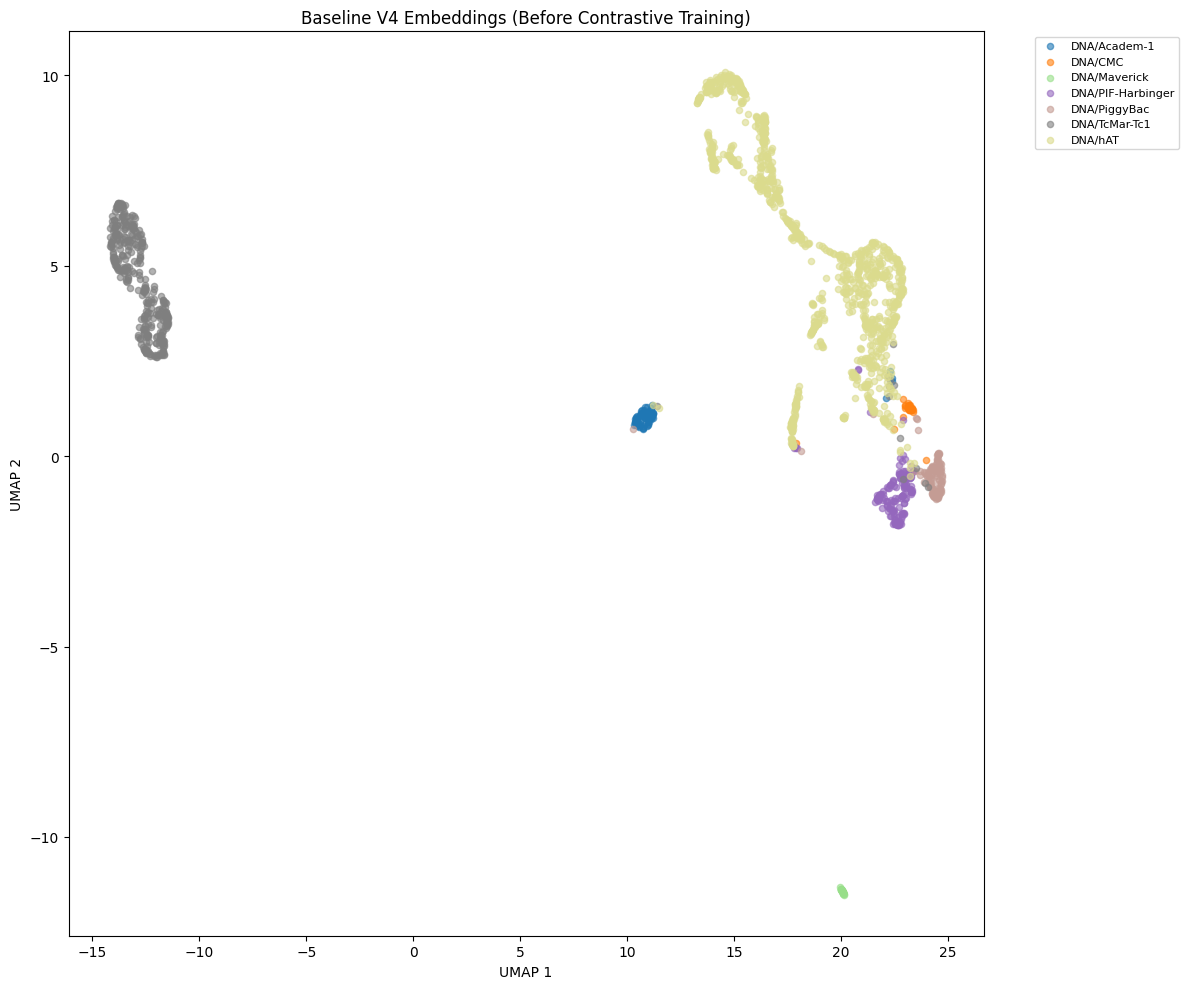

In [23]:
# Visualize baseline UMAP
print("\nBaseline UMAP visualization:")
_ = plot_umap(
    fused_baseline, 
    sf_ids_baseline, 
    label_names=sf_names,
    title="Baseline V4 Embeddings (Before Contrastive Training)",
    save_path="baseline_umap.png"
)

## Step 6: Train Contrastive Model

In [24]:
# Train the model using SupCon + Classification + Center Loss
model, history = train_supcon(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    encoder_lr_mult=ENCODER_LR_MULT,
    temperature=TEMPERATURE,
    classify_weight=CLASSIFY_WEIGHT,
    center_weight=CENTER_WEIGHT,
    center_lr=CENTER_LR,
    device=DEVICE,
    patience=15,
    save_dir=".",
    track_diagnostics=True
)

Training with Combined Loss: SupCon + Classification + Center
  Temperature: 0.3
  Classification weight: 0.5
  Center loss weight: 0.01
  Encoder LR: 1.00e-05
  Head LR: 1.00e-04
  Center LR: 5.00e-01



Epoch 1/30:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch   1: loss=2.5754 (sc=2.323 ce=0.504) | sil=0.5601 | acc=0.976 | intra=0.796 inter=0.087 margin=0.709
  -> Saved checkpoint at epoch 1
  -> New best silhouette: 0.5601


Epoch 2/30:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch   2: loss=2.4002 (sc=2.319 ce=0.163) | sil=0.5416 | acc=0.979 | intra=0.768 inter=0.050 margin=0.718


...

Epoch  28: loss=2.2877 (sc=2.267 ce=0.042) | sil=0.5467 | acc=0.987 | intra=0.782 inter=0.052 margin=0.730


Epoch 29/30:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch  29: loss=2.3040 (sc=2.279 ce=0.051) | sil=0.5380 | acc=0.984 | intra=0.771 inter=0.038 margin=0.733


Epoch 30/30:   0%|          | 0/222 [00:00<?, ?it/s]

Epoch  30: loss=2.2946 (sc=2.272 ce=0.045) | sil=0.5470 | acc=0.986 | intra=0.781 inter=0.049 margin=0.732
  -> Saved checkpoint at epoch 30

TRAINING SUMMARY (SupCon + Classification + Center Loss)
Best val_loss: 2.2864
Best silhouette: 0.5601
Final silhouette: 0.5470
Final SF accuracy: 0.9864
Final intra-class similarity: 0.7810
Final inter-class similarity: 0.0491
Final margin (intra - inter): 0.7319


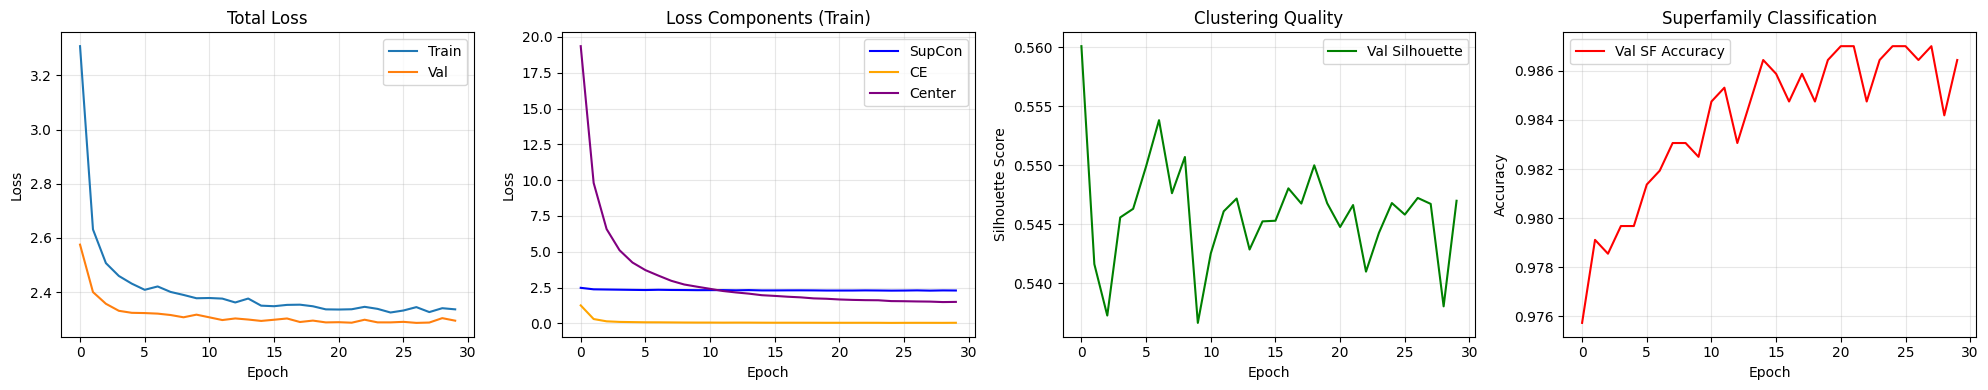

In [25]:
# Plot training history
plot_training_history(history, save_path="contrastive_training_history.png")

## Step 7: Evaluate After Contrastive Training

In [26]:
# Extract embeddings after contrastive training
print("Extracting post-training embeddings...")
z_post, fused_post, sf_ids_post, headers_post = extract_embeddings(
    model, val_loader, DEVICE
)

# Evaluate clustering with KMeans (6 clusters = macro structure)
print("\n=== Post-Training Clustering (K-Means, k=6) ===")
post_kmeans = evaluate_clustering(fused_post, sf_ids_post, method='kmeans')
print(f"  Silhouette: {post_kmeans['silhouette']:.4f} (baseline: {baseline_kmeans['silhouette']:.4f})")
print(f"  ARI: {post_kmeans['ari']:.4f} (baseline: {baseline_kmeans['ari']:.4f})")
print(f"  NMI: {post_kmeans['nmi']:.4f} (baseline: {baseline_kmeans['nmi']:.4f})")

# Evaluate with HDBSCAN (larger min_cluster_size for fewer, meaningful clusters)
print("\n=== Post-Training Clustering (HDBSCAN, min_cluster_size=100) ===")
post_hdbscan = evaluate_clustering(
    fused_post, sf_ids_post, method='hdbscan',
    hdbscan_min_cluster_size=100, hdbscan_min_samples=20
)
print(f"  Clusters found: {post_hdbscan['n_clusters']}")
print(f"  Silhouette: {post_hdbscan.get('silhouette', -1):.4f}")
print(f"  ARI: {post_hdbscan.get('ari', -1):.4f}")
print(f"  NMI: {post_hdbscan.get('nmi', -1):.4f}")

Extracting post-training embeddings...


Extracting embeddings:   0%|          | 0/56 [00:00<?, ?it/s]


=== Post-Training Clustering (K-Means, k=6) ===


  Silhouette: 0.4101 (baseline: 0.4773)
  ARI: 0.6834 (baseline: 0.6147)
  NMI: 0.8134 (baseline: 0.7419)

=== Post-Training Clustering (HDBSCAN, min_cluster_size=100) ===


  HDBSCAN: 240 noise points out of 1771
  Clusters found: 3
  Silhouette: 0.5775
  ARI: 0.8390
  NMI: 0.8477



Post-training UMAP visualization:
Computing UMAP projection...


/Users/alexyang/Documents/Part III System Biology/TE Classification/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved to contrastive_umap.png


/var/folders/9v/zbs2wngj1392rlfhxv3090wm0000gn/T/ipykernel_36635/4182542014.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20' if n_labels <= 20 else 'viridis')


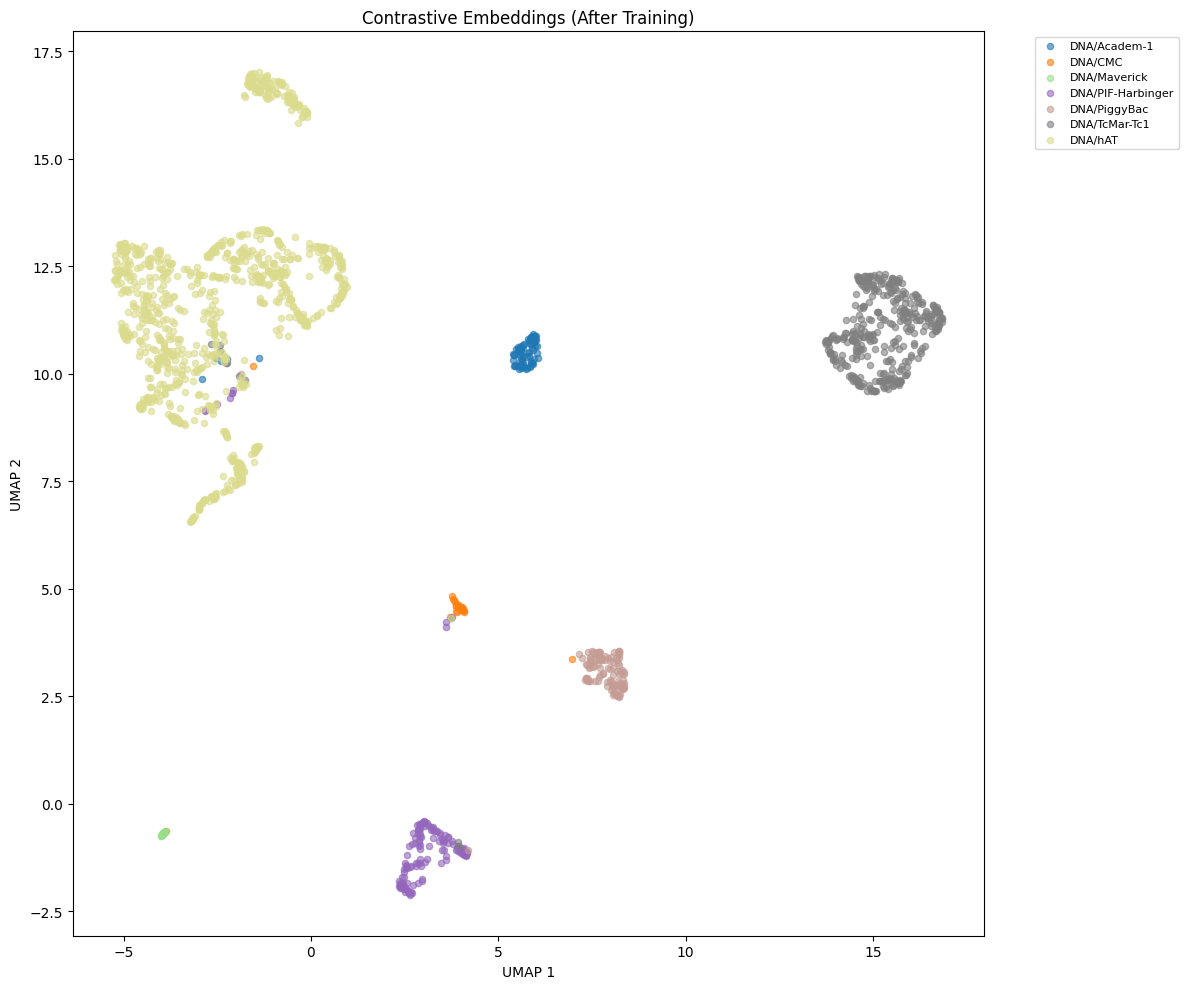

In [27]:
# Visualize post-training UMAP
print("\nPost-training UMAP visualization:")
_ = plot_umap(
    fused_post, 
    sf_ids_post, 
    label_names=sf_names,
    title="Contrastive Embeddings (After Training)",
    save_path="contrastive_umap.png"
)

## Step 8: Compare Baseline vs Contrastive Embeddings

In [28]:
# Summary comparison
print("=" * 60)
print("SUMMARY: Baseline vs Contrastive Training")
print("=" * 60)

comparison = pd.DataFrame({
    'Metric': ['Silhouette', 'ARI', 'NMI'],
    'Baseline (K-Means)': [
        baseline_kmeans['silhouette'],
        baseline_kmeans['ari'],
        baseline_kmeans['nmi']
    ],
    'Contrastive (K-Means)': [
        post_kmeans['silhouette'],
        post_kmeans['ari'],
        post_kmeans['nmi']
    ],
    'Improvement': [
        post_kmeans['silhouette'] - baseline_kmeans['silhouette'],
        post_kmeans['ari'] - baseline_kmeans['ari'],
        post_kmeans['nmi'] - baseline_kmeans['nmi']
    ]
})

print(comparison.to_string(index=False))

# Highlight improvements
print("\n" + "=" * 60)
for _, row in comparison.iterrows():
    metric = row['Metric']
    imp = row['Improvement']
    if imp > 0:
        print(f"✅ {metric}: +{imp:.4f} improvement")
    else:
        print(f"❌ {metric}: {imp:.4f} (decreased)")

SUMMARY: Baseline vs Contrastive Training
    Metric  Baseline (K-Means)  Contrastive (K-Means)  Improvement
Silhouette            0.477301               0.410134    -0.067167
       ARI            0.614656               0.683366     0.068710
       NMI            0.741883               0.813380     0.071497

❌ Silhouette: -0.0672 (decreased)
✅ ARI: +0.0687 improvement
✅ NMI: +0.0715 improvement


## Step 9: Save Final Model and Embeddings

In [29]:
# Save the final model
final_save_path = Path(".") / "contrastive_final.pt"
torch.save({
    'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
    'history': history,
    'arch': arch,
    'sf_names': sf_names,
    'sf_to_id': sf_to_id,
    'num_superfamilies': NUM_SUPERFAMILIES,
    'config': {
        'proj_dim': PROJ_DIM,
        'temperature': TEMPERATURE,
        'lr': LR,
        'encoder_lr_mult': ENCODER_LR_MULT,
        'classify_weight': CLASSIFY_WEIGHT,
        'center_weight': CENTER_WEIGHT,
        'center_lr': CENTER_LR,
    }
}, final_save_path)
print(f"Saved final model to {final_save_path}")

# Save embeddings for further analysis
embeddings_df = pd.DataFrame({
    'header': headers_post,
    'superfamily': [sf_names[i] for i in sf_ids_post],
    'sf_id': sf_ids_post,
    **{f'embed_{i}': fused_post[:, i] for i in range(fused_post.shape[1])}
})
embeddings_df.to_csv("contrastive_embeddings.csv", index=False)
print(f"Saved embeddings to contrastive_embeddings.csv ({len(embeddings_df)} rows)")

Saved final model to contrastive_final.pt


Saved embeddings to contrastive_embeddings.csv (1771 rows)
